<a href="https://colab.research.google.com/github/MM33NA/AI-machine-learning-projects/blob/main/exploratory-data-analysis/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Description**

Project statement:

AAL, established in 2000, is a well-known brand in Australia, particularly recognized for its clothing business. It has opened branches in various states, metropolises, and tier-1 and tier-2 cities across the country.

The brand caters to all age groups, from kids to the elderly.

Currently experiencing a surge in business, AAL is actively pursuing expansion opportunities. To facilitate informed investment decisions, the CEO has assigned the responsibility to the head of AAL’s sales and marketing (S&M) department. The specific tasks include:

- Identify the states that are generating the highest revenues.
- Develop sales programs for states with lower revenues.

The head of sales and marketing has requested your assistance with this task.
- Analyze the sales data of the company for the fourth quarter in Australia, examining it on a state-by-state basis.
- Provide insights to assist the company in making data-driven decisions for the upcoming year.

_Enclosed is the CSV (AusApparalSales4thQrt2020.csv) file that covers the said data._

#### **1. IMPORT LIBRARIES & LOAD DATA**

In [ ]:
# import the required libraries
import pandas as pd # Loads the Pandas library, which is a powerful tool for data analysis and manipulation.
import numpy as np # Loads the NumPy library, which is a fundamental package for scientific computing in Python.

# load the library packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os


In [ ]:
# Load the file to GitHub
# 1. Define the repository URL
repo_url = "https://github.com/MM33NA/AI-machine-learning-projects.git"
repo_name = "AI-machine-learning-projects"

# 2. Clone the repo
if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print("Repository already exists. Pulling latest changes...")
    %cd {repo_name}
    !git pull
    %cd ..

# 3. Move into specific sub-folder to access CSVs directly by name
os.chdir(f"{repo_name}/exploratory-data-analysis")

# 4. Verify the files are there
print("\n Files are ready:")
!ls

Cloning into 'AI-machine-learning-projects'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 35 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 548.18 KiB | 11.92 MiB/s, done.
Resolving deltas: 100% (5/5), done.

 Files are ready:
AusApparalSales4thQrt2020.csv  README.md  sales_analysis.ipynb


In [ ]:
# Load the dataset
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


#### **2. Data Wrangling**


In [ ]:
# Inspection for missing values and dtype
#print("Missing Values:\n", df.isna().sum())

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


**Observation:**
- [X] **Missing values:** There are no missing values in the data set. If missing values were present, we would use "dropna" for <5% loss or "fillna" with median for larger gaps. Currently, the data is clean with no missing values

- [ ] **Normalization:** Normalization for Unit and Sales required

- [ ] **Data type:** The data type for Date column needs to be changed as it is 'object(string) so we can create the graphs or perform further analysis.



In [ ]:
# c. Normalization
scaler = MinMaxScaler()

# We create a copy for normalized analysis to keep original Sales/Units for reporting
df_norm = df.copy()
df_norm[['Sales_Scaled', 'Unit_Scaled']] = scaler.fit_transform(df[['Sales', 'Unit']])
df_norm.head()

,Date,Time,State,Group,Unit,Sales,Sales_Scaled,Unit_Scaled
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


- [X] **Normalization:**
  -  We applied Min-Max Scaling to the Sales and Unit variables.
  - This is essential because Sales values are in the tens of thousands while Units are in double digits;
  - Normalization allows us to compare their relative distributions on a 0 to 1 scale

In [ ]:
# Convert Date and set as Index
# changes "Date" dtype 'object' --> dtype 'datetime'
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Time,State,Group,Unit,Sales
Date,,,,,
2020-10-01,Morning,WA,Kids,8,20000
2020-10-01,Morning,WA,Men,8,20000
2020-10-01,Morning,WA,Women,4,10000
2020-10-01,Morning,WA,Seniors,15,37500
2020-10-01,Afternoon,WA,Kids,3,7500


In [ ]:
# Extract Day of Week for Visualization
df['Day_of_Week'] = df.index.day_name()

df.head()

,Time,State,Group,Unit,Sales,Day_of_Week
Date,,,,,,
2020-10-01,Morning,WA,Kids,8,20000,Thursday
2020-10-01,Morning,WA,Men,8,20000,Thursday
2020-10-01,Morning,WA,Women,4,10000,Thursday
2020-10-01,Morning,WA,Seniors,15,37500,Thursday
2020-10-01,Afternoon,WA,Kids,3,7500,Thursday


- [X] **Date data type**     

  - Changed the dtype for 'Date' variable from 'object' to datetime.
  - It allow for chronological sorting, periodic grouping (Weekly/Monthly/Quarterly), and time-series plotting.

- **df.set_index:** Row labels are now actual calendar dates.

- **.day_name():** This is a special Pandas function that "looks" at a date (like 2020-10-01) and calculates what day of the week it was (in this case, a Thursday).

- **df['Day_of_Week']** This creates a new column in table named "Day_of_Week" and fills it with those names.df.set_index('Date') sets the data to actual calendar dates which makes it easier to extract the names of the day.


In [ ]:
# Variables that are categorical

df.select_dtypes(include='object').columns


Index(['Time', 'State', 'Group', 'Day_of_Week'], dtype='object')

In [ ]:
# Check the unique categories for each categorical variables
df['Time'].unique()


array([' Morning', ' Afternoon', ' Evening'], dtype=object)

In [ ]:
df['State'].unique()

array([' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS'], dtype=object)

In [ ]:
df['Group'].unique()

array([' Kids', ' Men', ' Women', ' Seniors'], dtype=object)

**Observation**
-  [ ] **Data Entry Error:** There's an extra spaces in all the categorical variables, Time, State, and Group

In [ ]:
# Clean column names and strip 'Time' strings
# Strip --> Removes the extra spaces from the values and cleans it.

df.columns = df.columns.str.strip()
df['Time'] = df['Time'].str.strip()

df.columns = df.columns.str.strip()
df['State'] = df['State'].str.strip()

df.columns = df.columns.str.strip()
df['Group'] = df['Group'].str.strip()

In [ ]:
# Check if the extra spaces were removed from values -- Time
df['Time'].unique()

array(['Morning', 'Afternoon', 'Evening'], dtype=object)

In [ ]:
# Check if the extra spaces were removed from values -- State

df['State'].unique()

array(['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS'], dtype=object)

In [ ]:
# Check if the extra spaces were removed from values -- Group

df['Group'].unique()

array(['Kids', 'Men', 'Women', 'Seniors'], dtype=object)

- [X] **Data entry error corrected:**
  - Stripped the extra spaces from the all the categorical variables

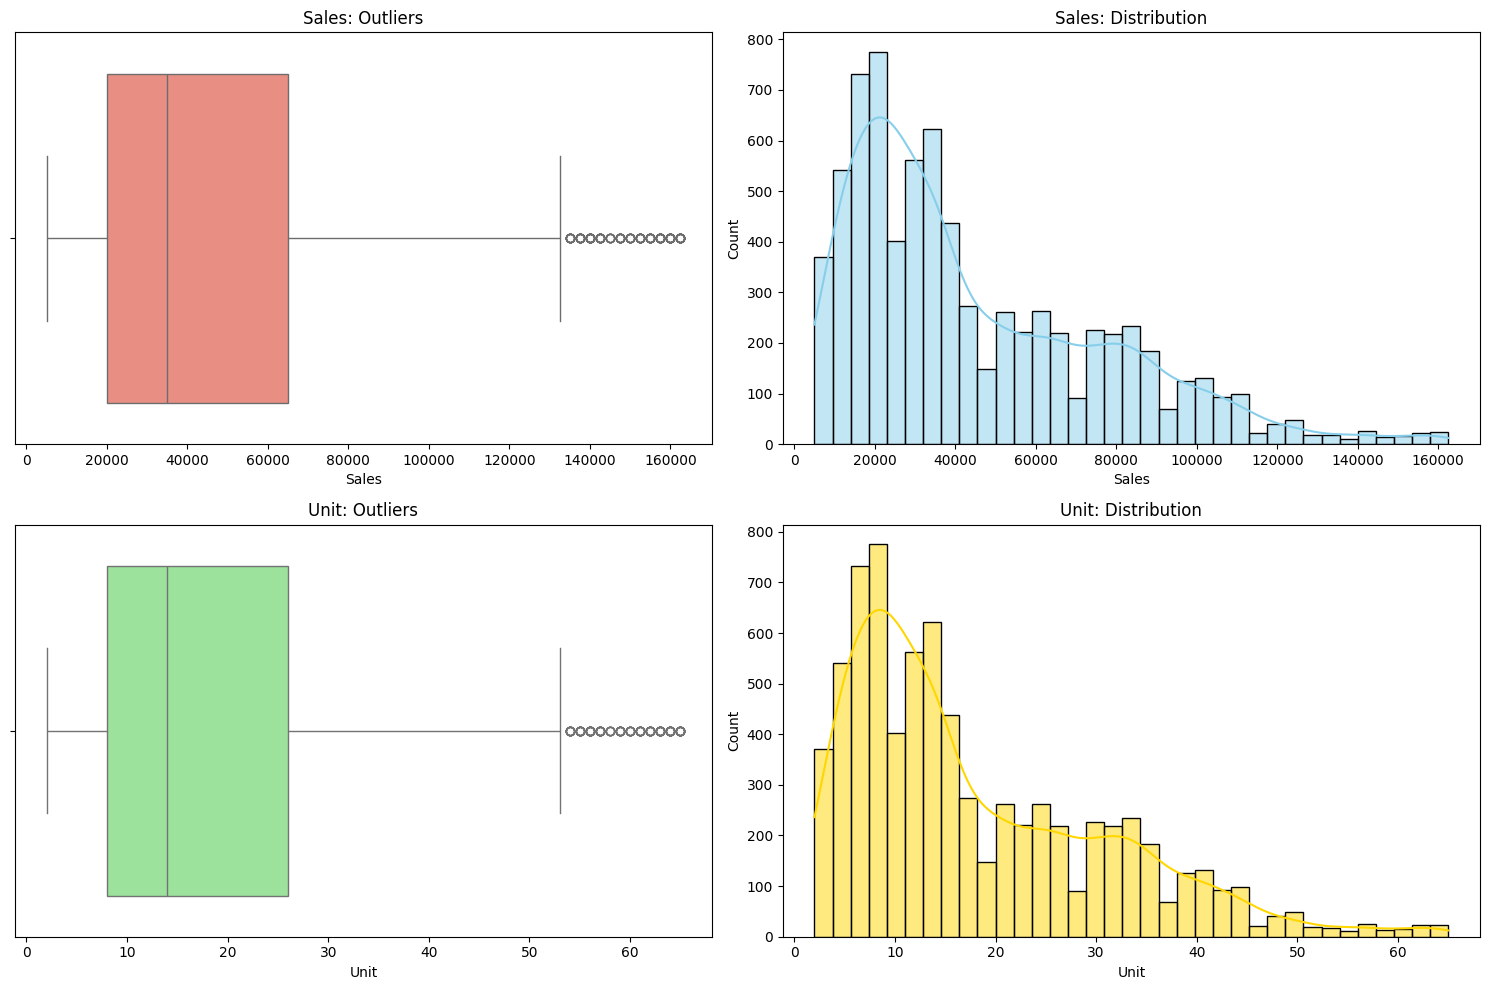

In [ ]:
# Create a 2x2 grid to check both Sales and Units
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Row 1: Sales ---
sns.boxplot(x=df['Sales'], color='salmon', ax=axes[0,0])
sns.histplot(df['Sales'], kde=True, color='skyblue', ax=axes[0,1])
axes[0,0].set_title('Sales: Outliers')
axes[0,1].set_title('Sales: Distribution')

# --- Row 2: Units ---
sns.boxplot(x=df['Unit'], color='lightgreen', ax=axes[1,0])
sns.histplot(df['Unit'], kde=True, color='gold', ax=axes[1,1])
axes[1,0].set_title('Unit: Outliers')
axes[1,1].set_title('Unit: Distribution')

plt.tight_layout()
plt.show()


We performed a dual-variable diagnostic check on Sales and Unit.

**Outlier Detection:** The boxplots reveal several high-value outliers in Sales and Units variable. However, these are not 'errors' but represent high-capacity transactions.

**Distribution Check:** Both variables show a right-skewed distribution. This visual evidence confirms that Normalization is the best wrangling technique to ensure these outliers do not disproportionately dominate the model."

**Data Wrangling Summary**

**1. Data Inventory & Quality**

- **Volume:** The dataset contains 7,560 entries for the 4th Quarter of 2020.

- **Integrity:** Verified using isna() and notna() functions. The dataset is 100% complete with no missing values.

- **Correction:** Identified and resolved "Object" data type errors for the Date column, casting it to datetime64[ns] to enable time-series analysis.

- **Syntax Cleaning:** Addressed data entry inconsistencies by applying the .strip() function to categorical variables (Time, State, Group), removing leading/trailing spaces that would have skewed group-level aggregates.

**2. Diagnostic Visualization (Outliers & Distribution)**

- **Outlier Analysis:** Boxplots revealed significant high-value outliers in both Sales and Unit counts. As these represent valid high-capacity transactions (up to $162,500), they were retained to ensure the analysis reflects true revenue potential.

- **Skewness:** Distribution curves (Seaborn distplots) confirm that both variables are right-skewed. This indicates that while the majority of sales are standard volume, a small segment of high-value orders drives a disproportionate amount of revenue.

**3. Strategic Technical Choices**

- **Normalization Choice:** Because the data is skewed and contains significant outliers, we chose Min-Max Normalization over Standardization. This scales the data into a fixed range [0, 1], preserving the relative relationships between small orders and "whale" transactions without assuming a normal (bell-curve) distribution.

In [ ]:
df.columns

Index(['Time', 'State', 'Group', 'Unit', 'Sales', 'Day_of_Week'], dtype='object')

- - -



#### **3. Data Analysis**

In [ ]:
# Descriptive Statistics
desc_stats = df[['Sales', 'Unit']].describe().T
desc_stats

,count,mean,std,min,25%,50%,75%,max
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0


In [ ]:
# Add mode
desc_stats['mode'] = [df['Sales'].mode()[0], df['Unit'].mode()[0]]
desc_stats

,count,mean,std,min,25%,50%,75%,max,mode
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0,22500
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0,9


**Observation:**
- The dataset with 7,560 transactions, shows a business with a high average transaction value and significant internal variance.
- Since the distribution of the data is right-skewed the average sales is notably higher than the median (Mean: 45,013 > Median: 35,000) because of high-value deals inflating the average.
- While the bottom 25% of sales start at 20,000, the top performers reach as high as 162,500.
- This volatility is further highlighted by a standard deviation of 32,253, indicating that while a typical "middle-of-the-road" sale falls between 20,000 and 65,000, there is a massive jump into the six-figure sales.
- In contrast, the Units sold remain relatively stable, with a median of 14 and a maximum of 65, suggesting that high revenue is driven more by high price points or premium services than by massive bulk orders of units.

In [ ]:
# Highest and Lowest Sales Groups

group_sales = df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales_unit = df.groupby('Group')['Unit'].sum().sort_values(ascending=False)


# logic: idxmax() should pair with .max(), idxmin() with .min()
print(f"\nHighest Sales Group: {group_sales.idxmax()} (${group_sales.max():,.0f})")
print(f"Lowest Sales Group: {group_sales.idxmin()} (${group_sales.min():,.0f})")
print(f"\nHighest Unit Sold Group: {group_sales_unit.idxmax()} ({group_sales_unit.max():,.0f})")
print(f"Lowest Unit Sold Group: {group_sales_unit.idxmin()}({group_sales_unit.min():,.0f})")



Highest Sales Group: Men ($85,750,000)
Lowest Sales Group: Seniors ($84,037,500)

Highest Unit Sold Group: Men (34,300)
Lowest Unit Sold Group: Seniors(33,615)


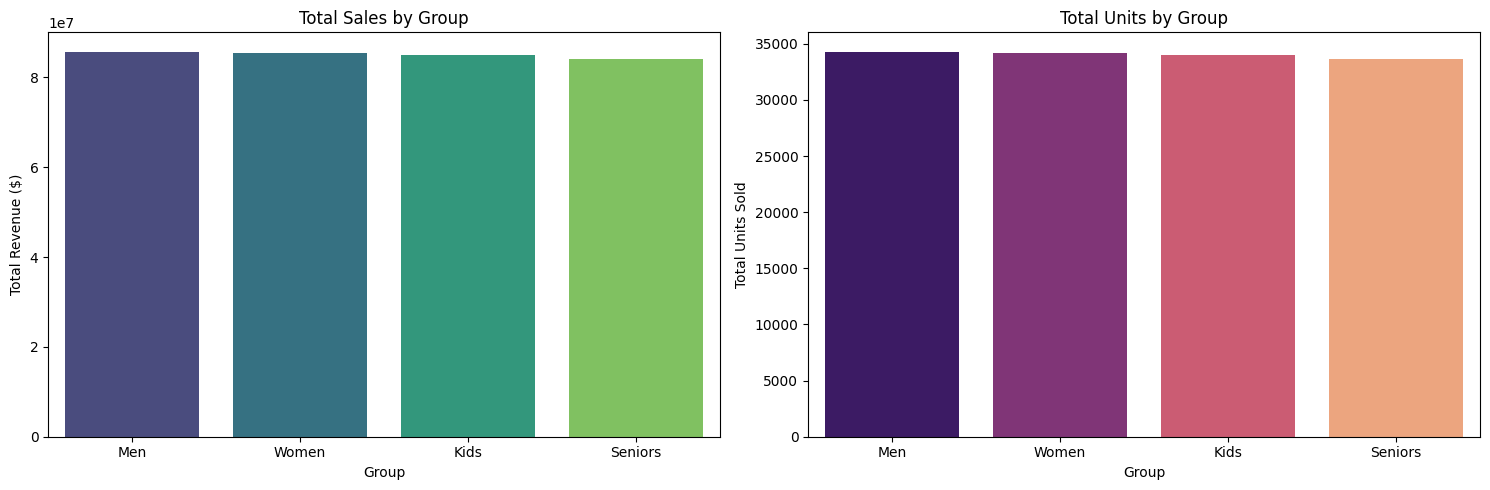

In [ ]:

# Visualize for more clear picture
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Sales Chart
sns.barplot(
    x=group_sales.index,
    y=group_sales.values,
    ax=ax[0],
    hue=group_sales.index,  # Assign x to hue for coloring
    palette="viridis",
    legend=False           # Hide the legend since it's redundant
)
ax[0].set_title('Total Sales by Group')
ax[0].set_ylabel('Total Revenue ($)')

# Unit Chart
sns.barplot(
    x=group_sales_unit.index,
    y=group_sales_unit.values,
    ax=ax[1],
    hue=group_sales_unit.index, # Assign x to hue for coloring
    palette="magma",
    legend=False                # Hide the legend
)
ax[1].set_title('Total Units by Group')
ax[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

**Observation:** Surprisingly, there is no notable difference in sales performance between Men, Women, Kids, and Seniors. Each group contributes roughly 25% of the total volume, showing the products have a universal appeal across all age and gender segments.

Highest Sales Group: Men ($85,750,000)
Lowest Sales Group: Seniors ($84,037,500)

Highest Unit Sold Group: Men (34,300)
Lowest Unit Sold Group: Seniors(33,615)

In [ ]:
# Group by Time and sum the Sales
time_sales = df.groupby('Time')[['Sales', 'Unit']].sum().sort_values(by='Sales', ascending=False)
time_sales

,Sales,Unit
Time,,
Morning,114207500,45683
Afternoon,114007500,45603
Evening,112087500,44835


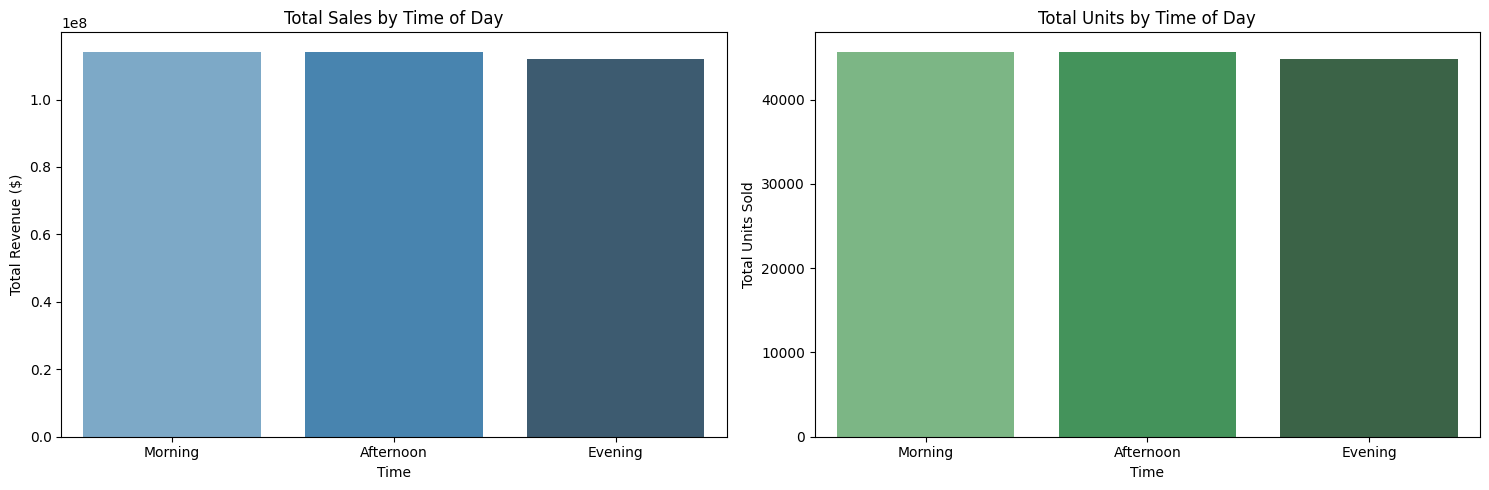

In [ ]:
# Visualize
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Sales by Time
sns.barplot(
    x=time_sales.index,
    y=time_sales['Sales'],
    ax=ax[0],
    hue=time_sales.index,
    palette="Blues_d",
    legend=False
)
ax[0].set_title('Total Sales by Time of Day')
ax[0].set_ylabel('Total Revenue ($)')

# Units by Time
sns.barplot(
    x=time_sales.index,
    y=time_sales['Unit'],
    ax=ax[1],
    hue=time_sales.index,
    palette="Greens_d",
    legend=False
)
ax[1].set_title('Total Units by Time of Day')
ax[1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.show()

In [ ]:
state_sales = df.groupby('State')[['Sales','Unit']].sum().sort_values(by='Sales', ascending=False)
state_sales

,Sales,Unit
State,,
VIC,105565000,42226
NSW,74970000,29988
SA,58857500,23543
QLD,33417500,13367
TAS,22760000,9104
NT,22580000,9032
WA,22152500,8861


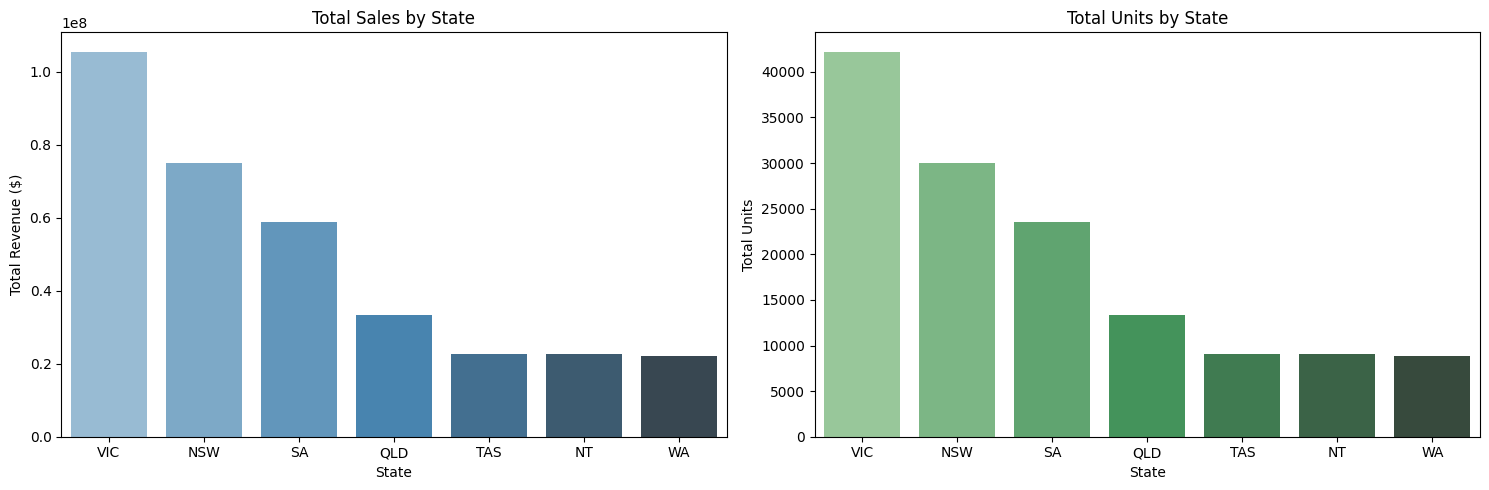

In [ ]:
# Visualize
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Sales by State
sns.barplot(
    x=state_sales.index,
    y=state_sales['Sales'],
    ax=ax[0],
    hue=state_sales.index,
    palette="Blues_d",
    legend=False
)
ax[0].set_title('Total Sales by State')
ax[0].set_ylabel('Total Revenue ($)')

# Units by State
sns.barplot(
    x=state_sales.index,
    y=state_sales['Unit'],
    ax=ax[1],
    hue=state_sales.index,
    palette="Greens_d",
    legend=False
)
ax[1].set_title('Total Units by State')
ax[1].set_ylabel('Total Units')

plt.tight_layout()
plt.show()

**Geographic Dominance:** Sales are heavily concentrated in VIC (Victoria) with total sales of 105565000, which generates more than 4.5 times the revenue of lowest-performing state (WA).

#### **Data Segregation: Weekly, Monthly, and Quaterly**

In [ ]:
# Weekly, Monthly, and Quarterly Data
weekly_report = df[['Sales', 'Unit']].resample('W').sum()
monthly_report = df[['Sales', 'Unit']].resample('M').sum()
quarterly_report = df[['Sales', 'Unit']].resample('Q').sum()

/tmp/ipykernel_610/4013518206.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_report = df[['Sales', 'Unit']].resample('M').sum()
/tmp/ipykernel_610/4013518206.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_report = df[['Sales', 'Unit']].resample('Q').sum()


**Note:** We utilized Pandas' frequency aliases ('W', 'M', 'Q') to resample the transaction data. This allowed for an automated aggregation of sales metrics into weekly, monthly, and quarterly snapshots, ensuring the timeline remains chronologically accurate.



#### **4. DATA VISUALIZATION DASHBOARD**

> Add blockquote



/tmp/ipykernel_610/1850377289.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df.reset_index(), x='State', y='Sales', hue='Group', estimator=np.sum, ci=None)


Text(0.5, 1.0, 'State-wise Sales by Demographics')

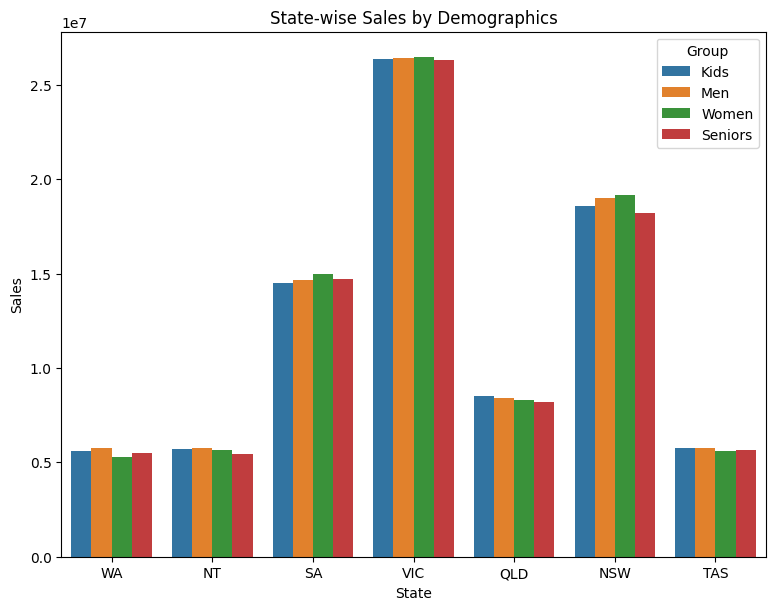

In [ ]:
# Create a multi-plot dashboard

fig = plt.figure(figsize=(20, 15))

# Plot 1: State-wise Sales by Demographics
plt.subplot(2,2,1)
sns.barplot(data=df.reset_index(), x='State', y='Sales', hue='Group', estimator=np.sum, ci=None)
plt.title('State-wise Sales by Demographics')

#

Text(0.5, 1.0, 'Heatmap: Group Performance by State')

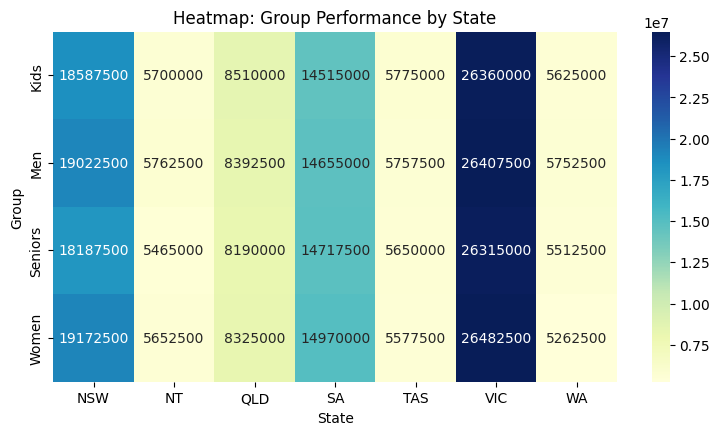

In [ ]:
# Plot 2: Group-wise Sales across States (Heatmap)
fig = plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
state_group_pivot = df.pivot_table(index='Group', columns='State', values='Sales', aggfunc='sum')
sns.heatmap(state_group_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Group Performance by State')

/tmp/ipykernel_610/3024088866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Time', y='Sales', palette="Set2")


Text(0.5, 1.0, 'Sales Distribution by Time of Day(Peak vs Off-Peak)')

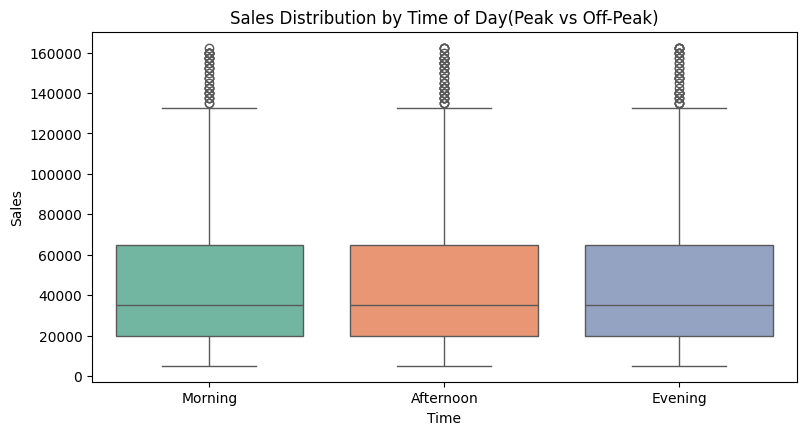

In [ ]:
# Plot 3: Time-of-the-day Analysis
fig = plt.figure(figsize=(20, 10))
plt.subplot(2,2,3)

sns.boxplot(data=df, x='Time', y='Sales', palette="Set2")
plt.title('Sales Distribution by Time of Day(Peak vs Off-Peak)')

Text(0.5, 0, 'Weekly Total Sales Trend')

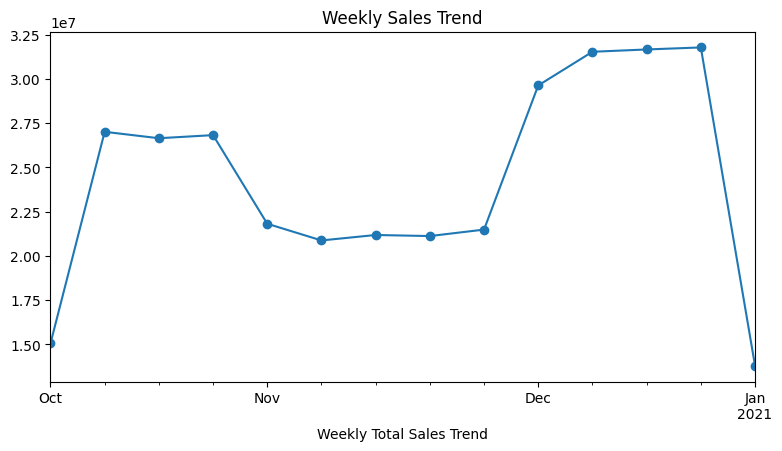

In [ ]:
# Plot 4: Weekly Trend
fig = plt.figure(figsize=(20, 10))
plt.subplot(2,2,4)
weekly_report['Sales'].plot(kind='line', marker='o')
plt.title('Weekly Sales Trend')
plt.xlabel('Weekly Total Sales Trend')

#plt.tight_layout()
#plt.show()

#### **STATISTICAL PLOTTING**

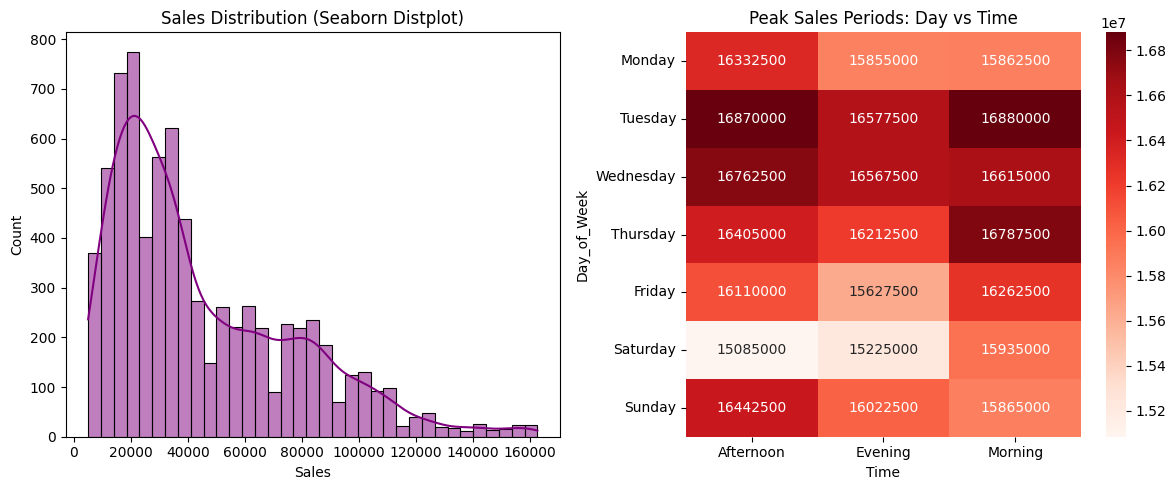

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Sales'], kde=True, color='purple')
plt.title('Sales Distribution (Seaborn Distplot)')

plt.subplot(1,2,2)
# Using a heatmap for Day of Week vs Time as the "Dashboard"
day_time_pivot = df.pivot_table(index="Day_of_Week", columns="Time", values="Sales", aggfunc="sum")
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_time_pivot = day_time_pivot.reindex(days)
sns.heatmap(day_time_pivot, annot=True, fmt=".0f", cmap="Reds")
plt.title('Peak Sales Periods: Day vs Time')

plt.tight_layout()
plt.show()

In [ ]:
# b. Handling Missing/Incorrect Data


In [ ]:
# to check the null or not null values
#df.isna().sum()
#df.notna().sum()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7560 entries, 2020-10-01 to 2020-12-30
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time         7560 non-null   object
 1   State        7560 non-null   object
 2   Group        7560 non-null   object
 3   Unit         7560 non-null   int64 
 4   Sales        7560 non-null   int64 
 5   Day_of_Week  7560 non-null   object
dtypes: int64(2), object(4)
memory usage: 413.4+ KB


In [ ]:
# to see the variables that are categorical
df.select_dtypes(include='object').columns

Index(['Time', 'State', 'Group', 'Day_of_Week'], dtype='object')

**_Note._** Convert 'Date' from string to datetime objects to allow for chronological sorting, periodic grouping (Weekly/Monthly/Quarterly), and time-series plotting.

In [ ]:
# check the unique categories for the variable Time
df['Time'].unique()

array(['Morning', 'Afternoon', 'Evening'], dtype=object)

In [ ]:
# check the unique categories for the variable State
df['State'].unique()

array(['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS'], dtype=object)

In [ ]:
# check the unique categories for the variable Group
df['Group'].unique()

array(['Kids', 'Men', 'Women', 'Seniors'], dtype=object)

**Observations**

**_Data description:_**
- The sample size for this study is 7560.
- There are six variables in the data.
- Three of them are categorical variables:
  - Time (' Morning', ' Afternoon', ' Evening')
  - State (' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS')
  - Group (' Kids', ' Men', ' Women', ' Seniors'

- There 1 datetime variable

- While 2 of them are integer class
  - Unit
  - Sales
- There are no null/missing values in the data.

**_Missing cases_**

- There are no missing values in any of the variables.

**_Data Type_**

- The Date data type was changed from object(string) to datetime datatype.
- All the other datatypes are correct and no changes are required.

#### **Histogram**

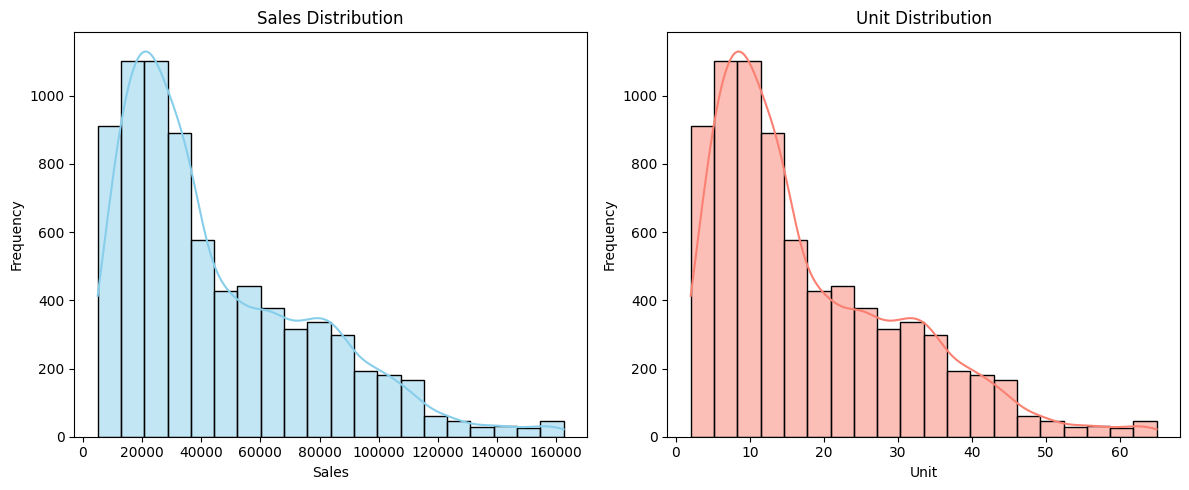

In [ ]:
# Create the 'canvas' with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First Chart: Sales (Notice: sns.histplot goes FIRST, then we define the ax)
sns.histplot(df['Sales'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Second Chart: Unit
sns.histplot(df['Unit'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Unit Distribution')
axes[1].set_xlabel('Unit')
axes[1].set_ylabel('Frequency')

# Clean up the layout and show
plt.tight_layout()
plt.show()

**Observations (histogram):**
- **Right-Skewed Distribution:** The peak (mode) is around 20,000, but the data stretches all the way to 160,000. This "skew" means that while most sales are small, the higher values are frequent enough to create a long slope.

- **Deviation from Normality:** The line chart shows that the data is not normally distributed.


- **Identical Distribution Patterns:** Both Sales and Unit exhibit a nearly identical Right-Skewed shape. This suggests a very strong linear relationship between the two variables—as the number of units increases, the sales value increases proportionally.

- **Peak Activity (Mode):** Most transactions involve approximately 8–10 units.

Most transaction values hover around $20,000.

**The "Long Tail" Logic:** The outliers we saw in the Sales boxplot (the $160k values) correspond directly to the outliers in the Unit distribution (the 60+ unit values).

Insight: These aren't "expensive single items"; these are bulk purchases.

Non-Normality: Neither variable follows a Gaussian (Normal) distribution. Both have "fat tails," meaning the business frequently sees high-volume orders that fall outside the "standard" day-to-day range.

#### **Boxplot**

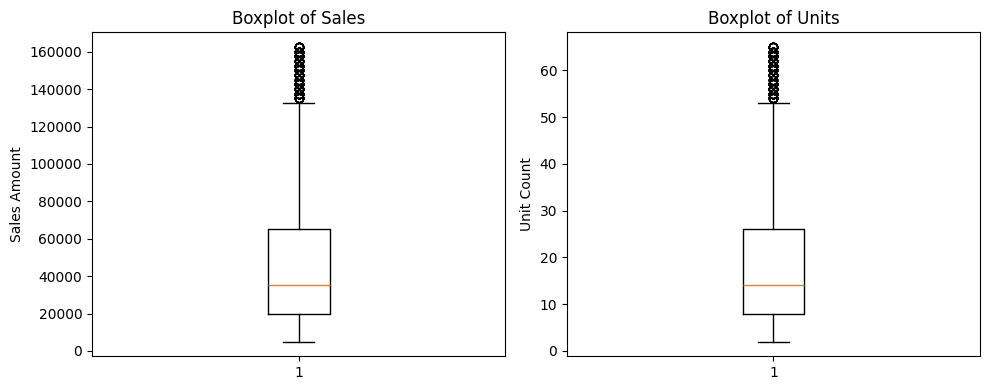

In [ ]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot Sales in the first spot
axes[0].boxplot(df['Sales'])
axes[0].set_title('Boxplot of Sales')
axes[0].set_ylabel('Sales Amount')

# Plot Unit in the second spot
axes[1].boxplot(df['Unit'])
axes[1].set_title('Boxplot of Units')
axes[1].set_ylabel('Unit Count')

plt.tight_layout() # Prevents the charts from overlapping
plt.show()

**Observations (boxplot):**

- **Positive (Right) Skewness:** The median line (orange) is positioned closer to the bottom of the box, and the upper "whisker" is significantly longer than the lower one. This indicates that most sales transactions are for smaller amounts, while a few transactions are much higher.

- **Presence of Significant Outliers:** There is a dense cluster of outliers (represented by circles) starting above 130,000 and extending up to 160,000.

- **Central Tendency:** The Median sales value sits at approximately 35,000, which is a more reliable "typical" value for this dataset than the mean due to the skewness.

- **Interquartile Range (IQR):** The middle 50% of sales fall roughly between 20,000 and 65,000. This defines our "normal" range for typical business activity.

#### **Scatter Plot**

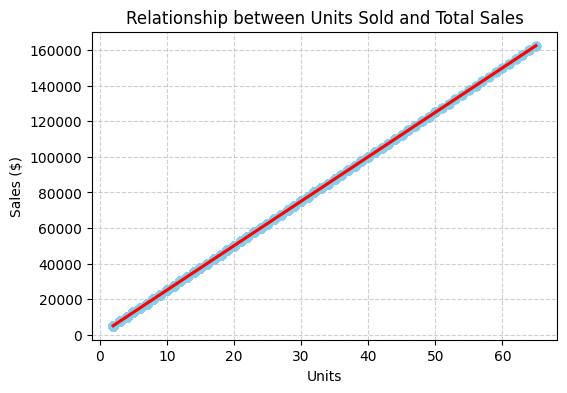

In [ ]:
plt.figure(figsize=(6, 4))

# Create the scatter plot
# 'reg' adds a regression line to show the linear trend
sns.regplot(data=df, x='Unit', y='Sales',
            scatter_kws={'alpha':0.5, 'color':'skyblue'},
            line_kws={'color':'red'})

plt.title('Relationship between Units Sold and Total Sales')
plt.xlabel('Units')
plt.ylabel('Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Observations (scatterplot)**
- **Perfect Positive Correlation:** There is a near-perfect linear relationship between Units and Sales. As the number of units increases, the sales value increases at a completely predictable rate.

- **Constant Price Point:** Because the dots fall almost exactly on the red regression line with almost no "noise" or "jitter," it indicates that the Price per Unit is constant across the entire dataset (or the variation in price is extremely negligible).

**Strategic Note:**

**Handling Outliers & Normalization**

**Decision:** The outliers identified in the Boxplot and the right-skewed distribution seen in the Histogram will be retained, and formal normalization (like Scaling or Log Transformation) will not be applied at this stage.

**Reasoning:**

_Preserving Business Reality:_ In sales data, extreme values are often "true" events (e.g., holiday peaks or bulk orders). Removing them would lead to an underestimation of total revenue potential.

#### **2. Data Analysis**

Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.


In [ ]:
descriptive_stats = df[['Sales', 'Unit']].describe().T
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Sales,7560.0,45013.558201,32253.506944,5000.0,20000.0,35000.0,65000.0,162500.0
Unit,7560.0,18.005423,12.901403,2.0,8.0,14.0,26.0,65.0


The dataset with 7,560 transactions, shows a business with a high average transaction value and significant internal variance. The average sale stands at 45,013, which is notably higher than the median of 35,000. This suggests a right-skewed distribution where several high-value deals are inflating the average.

The most striking insight is the extreme range of revenue; while the bottom 25% of sales start at 20,000, the top performers reach as high as 162,500. This volatility is further highlighted by a standard deviation of 32,253, indicating that while a typical "middle-of-the-road" sale falls between 20,000 and 65,000, there is a massive jump into the six-figure territory for top-tier clients. In contrast, the Units sold remain relatively stable, with a median of 14 and a maximum of 65, suggesting that high revenue is driven more by high price points or premium services than by massive bulk orders of units.

Identify the group with the highest sales and the group with the lowest sales based on the data provided.

In [ ]:
df.columns

Index(['Time', 'State', 'Group', 'Unit', 'Sales', 'Day_of_Week'], dtype='object')

In [ ]:
#df.groupby('Time')['Sales'].sum().sort_values()
# data.groupby('categorical variable')['Numeric variable'].aggregation().sort_values()

df.groupby('Time')[['Unit','Sales']].sum().sort_values(by='Sales', ascending=False).T

Time,Morning,Afternoon,Evening
Unit,45683,45603,44835
Sales,114207500,114007500,112087500


**Time:** There's no notable difference between the sales time. The sales are almost the same in morming, afternoon, and evening

In [ ]:
df.groupby('State')[['Unit', 'Sales']].sum().sort_values(by='Sales', ascending=False).T

State,VIC,NSW,SA,QLD,TAS,NT,WA
Unit,42226,29988,23543,13367,9104,9032,8861
Sales,105565000,74970000,58857500,33417500,22760000,22580000,22152500


**Geographic Dominance:** Sales are heavily concentrated in VIC (Victoria), which generates more than 4.5 times the revenue of lowest-performing state (WA).

In [ ]:
df.groupby('Group')[['Unit','Sales']].sum().sort_values(by='Sales', ascending=False).T

Group,Men,Women,Kids,Seniors
Unit,34300,34177,34029,33615
Sales,85750000,85442500,85072500,84037500


**Demographic Equality:** Surprisingly, there is no difference in sales performance between Men, Women, Kids, and Seniors. Each group contributes roughly 25% of the total volume, showing the products have a universal appeal across all age and gender segments.

In [ ]:
df.columns

Index(['Time', 'State', 'Group', 'Unit', 'Sales', 'Day_of_Week'], dtype='object')

#### **3a. Data Analysis - Groupby**

In [ ]:
# 2. Filter/slice data by Date range
df.set_index('Date', inplace=True)
df.head()

KeyError: "None of ['Date'] are in the columns"

In [ ]:
# Monthly Sales Summary
monthly_summary = df.resample('M')['Sales'].sum()
monthly_summary

In [ ]:
# Quarterly Unit Volume summar
quarterly_summary = df.resample('Q')['Unit'].mean()
quarterly_summary

In [ ]:
df['Sales'].plot(kind='line', figsize=(12, 6))

##**DASHBOARD**

In [ ]:
print(df.columns)


In [ ]:
# Drop the redundant columns since the index handles the timeline
df = df.drop(columns=['Date', 'Year', 'Month', 'Day'])

# Now your columns will just be: Time, State, Group, Unit, Sales
print(df.head())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract Day of Week from the Index
df['Day_of_Week'] = df.index.day_name()

# 2. Clean the 'Time' column (remove the leading spaces like ' Morning')
df['Time'] = df['Time'].str.strip()

# 3. Create Pivot Table for the Heatmap
# We'll look at the average 'Sales' for each time slot
heatmap_data = df.pivot_table(index='Day_of_Week',
                             columns='Time',
                             values='Sales',
                             aggfunc='mean')

# 4. Reorder days so they follow a natural week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

# 5. Plotting
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Average Sales by Day and Time')
plt.ylabel('Day of the Week')
plt.xlabel('Shift Period')
plt.show()